Ms. Isha Panjwani

![OIP.jpg](attachment:OIP.jpg)

# Logistic Regression

* Logistic Regression is one of the most popular machine learning Algorithm, Which comes under the supervised Machine Learning

* It is used to predict the categorical dependent variable
* its work on Binary Classification problem like 0,1


![94846291-bedcf080-03d5-11eb-9652-ea72f5f9ce42.png](attachment:94846291-bedcf080-03d5-11eb-9652-ea72f5f9ce42.png)

## Assumption for Logistic Regression

1. The dependent variable must be categorical in nature.
2. Independent variable should not multi-collinearity
3. the Dependent variable should be two category than it will perform well
  Because its work on Binary classification

![logistic-regression-in-machine-learning.png](attachment:logistic-regression-in-machine-learning.png)

### What is Sigmoid Function in Logistic Regression ?

* It is mathematically Function used to map the predicted values to Probabilities
* We use Sigmoid function For Binary classifiaction
* This function map any real value between 0 and 1 in Machine Learning


### There Are Three Types of Logistic Regression
1. Binomial Logistic Regression
2. Multinomial Logistic Regression
3. Ordinal Logistic regression


## For Logistic Regression

![1_k2bLmeYIG7z7dCyxADedhQ.png](attachment:1_k2bLmeYIG7z7dCyxADedhQ.png)

## Importing the usefull Library

In [ ]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as mns
import scipy.stats as st
import plotly.express as px
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,StandardScaler,MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score,ConfusionMatrixDisplay
from pandas_profiling import profile_report

### Preprocessing the data

In [ ]:
df=pd.read_csv("Loan_will_approve.csv")

In [ ]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [ ]:
df.shape

(614, 13)

There is 13 columns and 614 Rows in this dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


## Cheaking the Null Value

In [ ]:
na=df.isna().sum().reset_index().rename(columns={0:"Null"}).sort_values("Null",ascending=False)
na

,index,Null
10,Credit_History,50
5,Self_Employed,32
8,LoanAmount,22
3,Dependents,15
9,Loan_Amount_Term,14
1,Gender,13
2,Married,3
0,Loan_ID,0
4,Education,0
6,ApplicantIncome,0


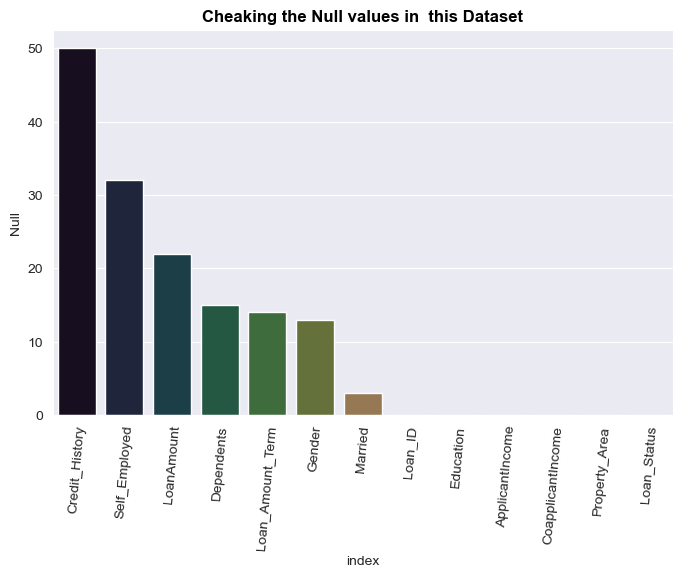

In [ ]:
#sns.set(rc={'axes.facecolor':'lightblue','figure.facecolor':"white"})
sns.set_style("darkgrid")
plt.figure(figsize=(8,5))
sns.barplot(data=na,x="index",y="Null",palette="cubehelix")
plt.xticks(rotation=85)
plt.title("Cheaking the Null values in  this Dataset",fontweight="bold",color="black")
plt.show()

* In this barplot i can easily visulize that there is seven 7 columns in Null value

# OR

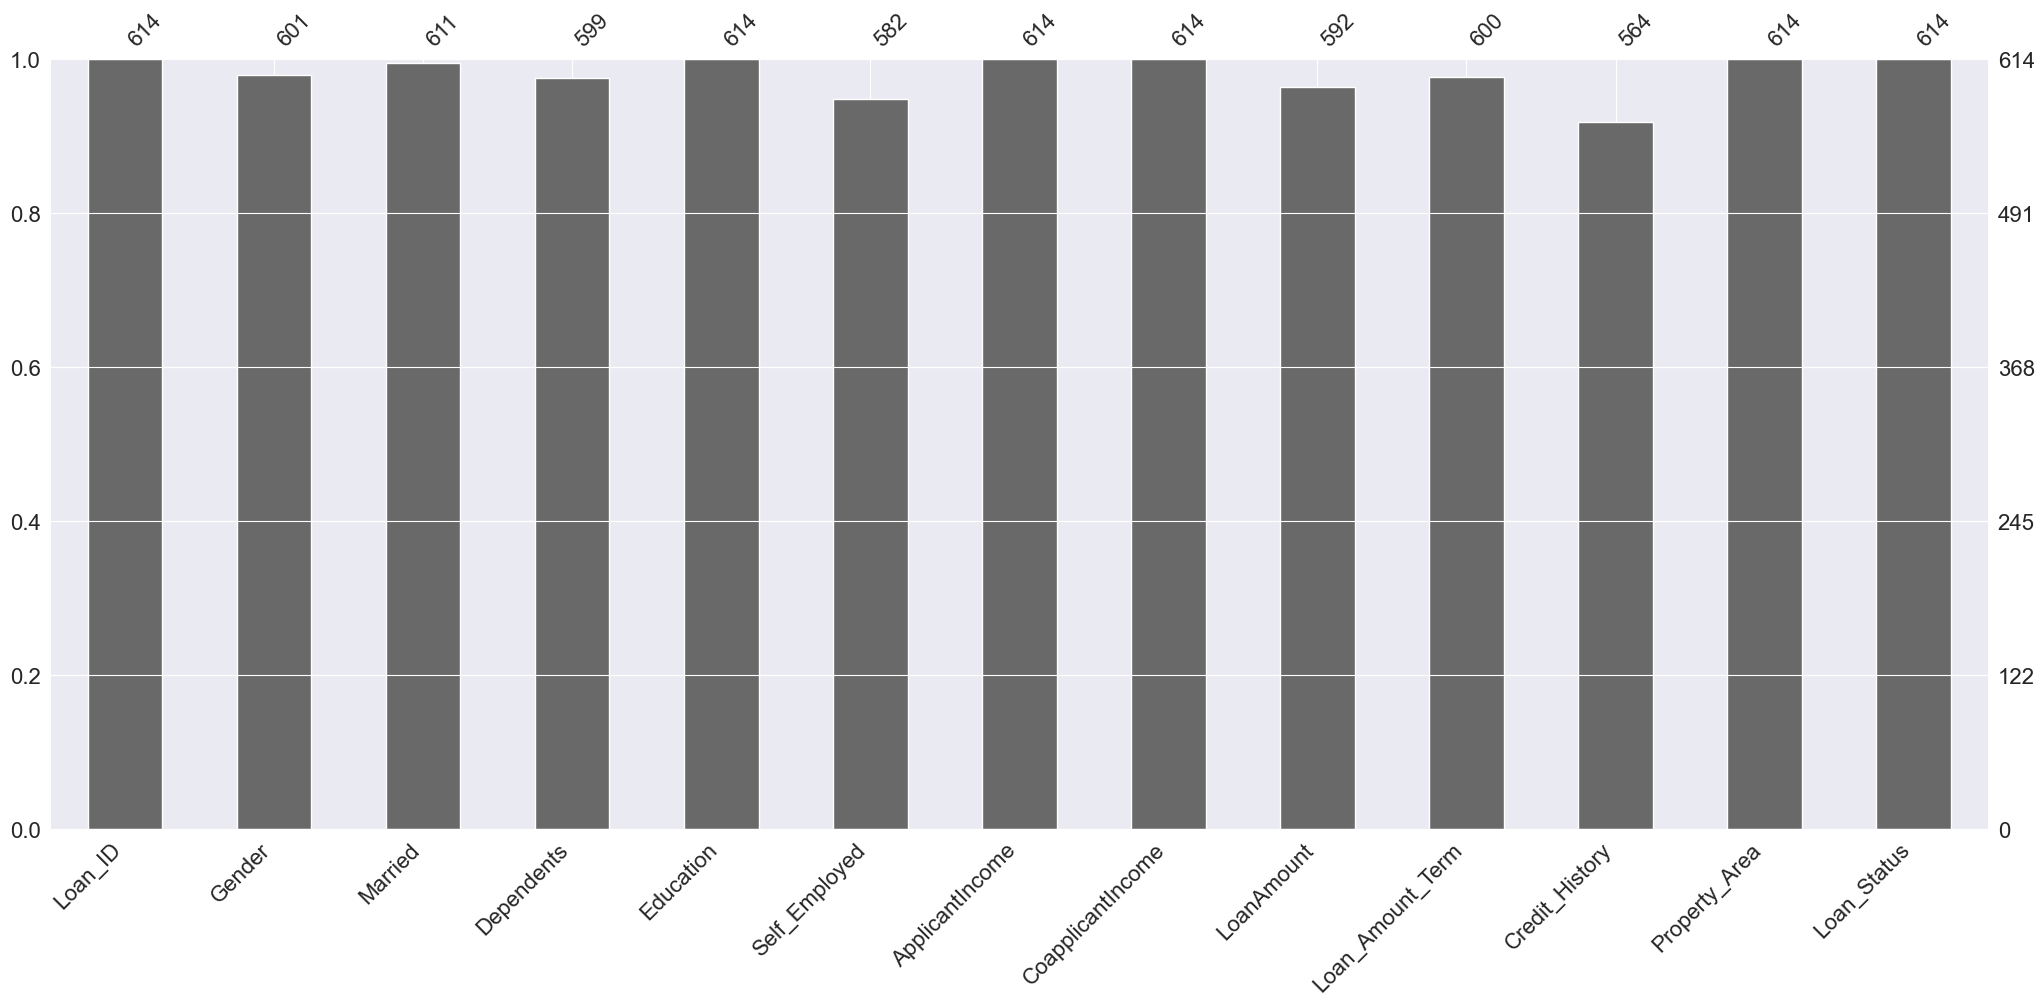

In [ ]:
mns.bar(df);

With the Help of Missingo Library in easily visulize the columns of Null value

#### Remove the Null values or Fill the null values with the help of mean ,median and Mode
* We are going to drop the Loan_id Columns that's useless for the Machine Learning Model
* And Other in fillna

In [ ]:
df.drop(columns="Loan_ID",inplace=True)

In [ ]:
df.head(3)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y


In [ ]:
for i in df:
    if df[i].isna().any():
        if df[i].dtypes=="float":
            if df[i].mean()-df[i].median()>10:
                df[i].fillna(df[i].median(),inplace=True)
            else:
                df[i].fillna(df[i].mean(),inplace=True)
        elif df[i].dtypes=="object":
            df[i].fillna(df[i].mode()[0],inplace=True)

In [ ]:
df.head(3)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y


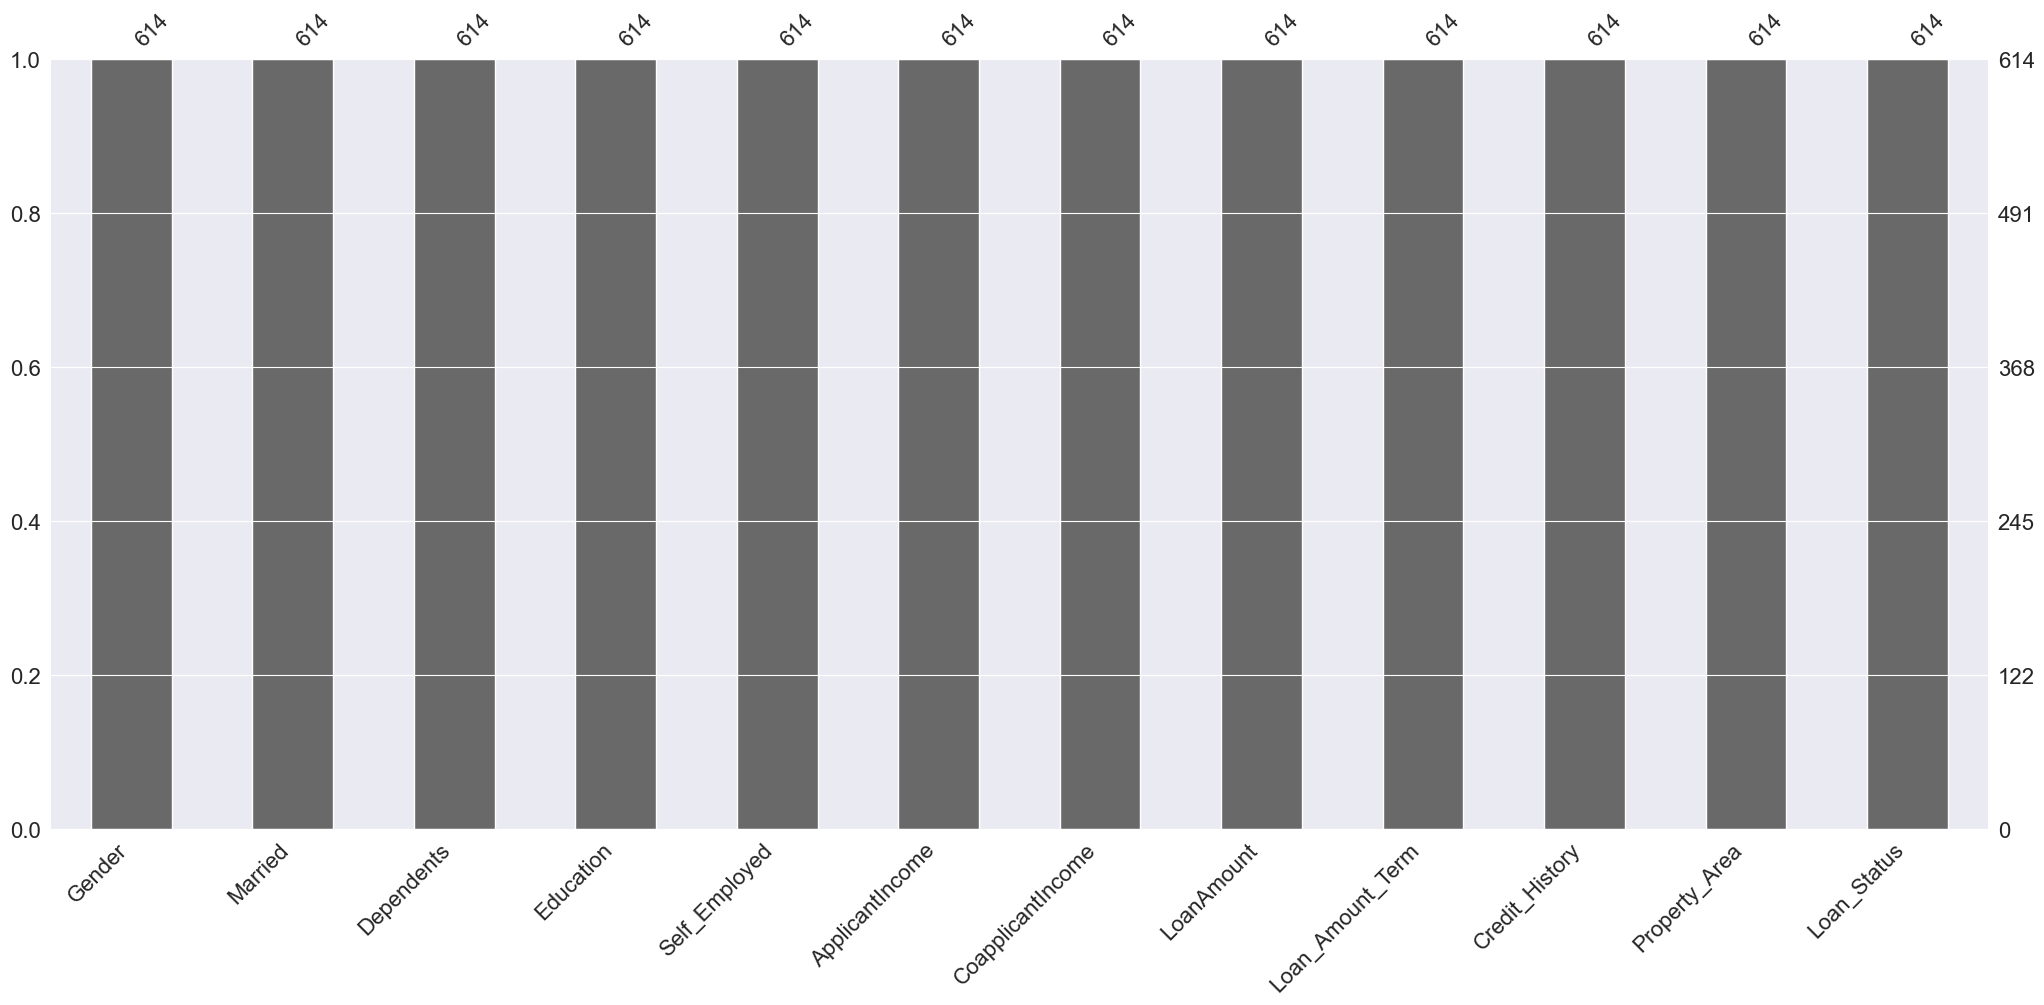

In [ ]:
mns.bar(df);

In [ ]:
na=df.isna().sum().reset_index().rename(columns={0:"Null"}).sort_values("Null",ascending=False)
na

,index,Null
0,Gender,0
1,Married,0
2,Dependents,0
3,Education,0
4,Self_Employed,0
5,ApplicantIncome,0
6,CoapplicantIncome,0
7,LoanAmount,0
8,Loan_Amount_Term,0
9,Credit_History,0


#### All Null Values filled with the specified Conditions mean median and Mode


In [ ]:
df.tail()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


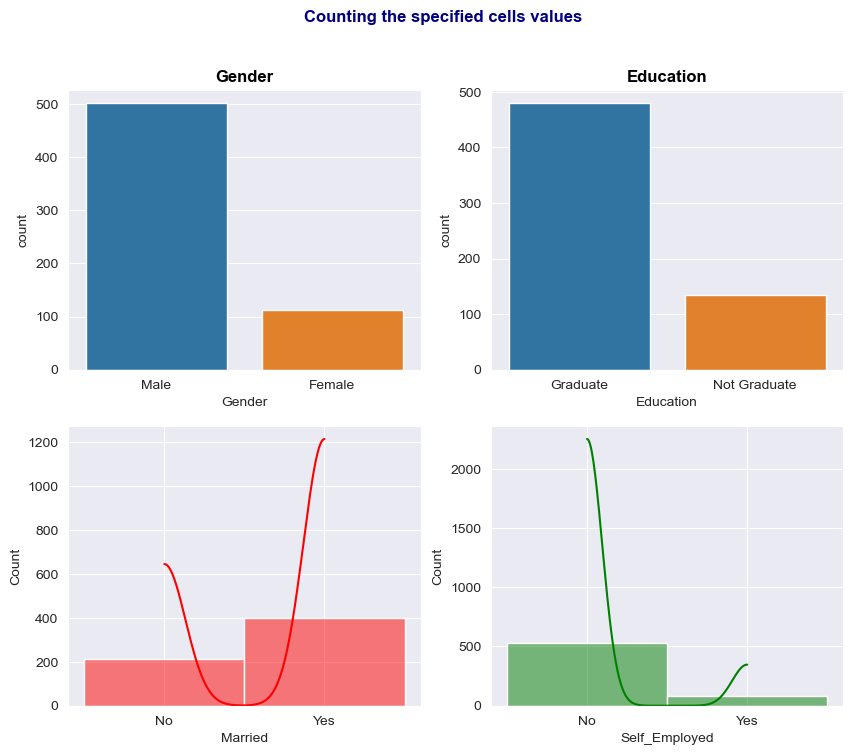

In [ ]:
plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
sns.countplot(df["Gender"])
plt.title("Gender",fontweight="bold",color="black")
plt.subplot(2,2,2)
sns.countplot(df['Education'])
plt.title("Education",fontweight="bold",color="black")
plt.subplot(2,2,3)
sns.histplot(df["Married"],kde=True,color="red")
#plt.title("Married",fontweight="bold",color="black")
plt.subplot(2,2,4)
sns.histplot(df['Self_Employed'],kde=True,color="Green")
#plt.title("Self_Employed",fontweight="bold",color="black")
plt.suptitle("Counting the specified cells values",fontweight="bold",color="navy")
plt.show()


## Here we easily show that

1. Number of Gender is male minimum gender is Female
2. There is the employee who is Approximate 490 Graduate and 130 Ungraduate
3. Number of married is maximum person is unmarried and minimum person is married
4. Maximum employees are not Self_Employed and minumum number employed are self Employed

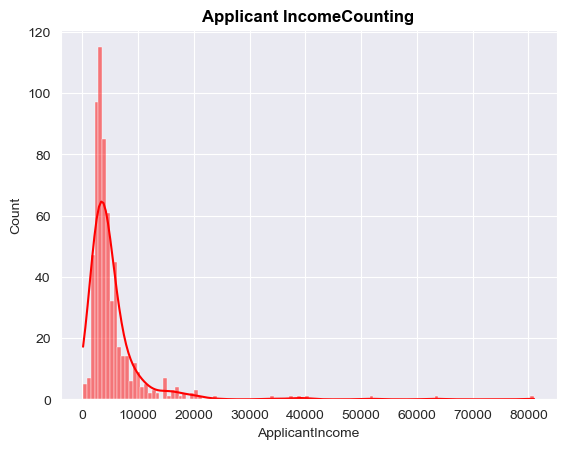

In [ ]:
sns.set_style("darkgrid")
sns.histplot(df["ApplicantIncome"],kde=True,color="red")
plt.title("Applicant IncomeCounting",fontweight="bold",color="black")
plt.show()

* Maximum Number of Applicant income between 200 to 800.

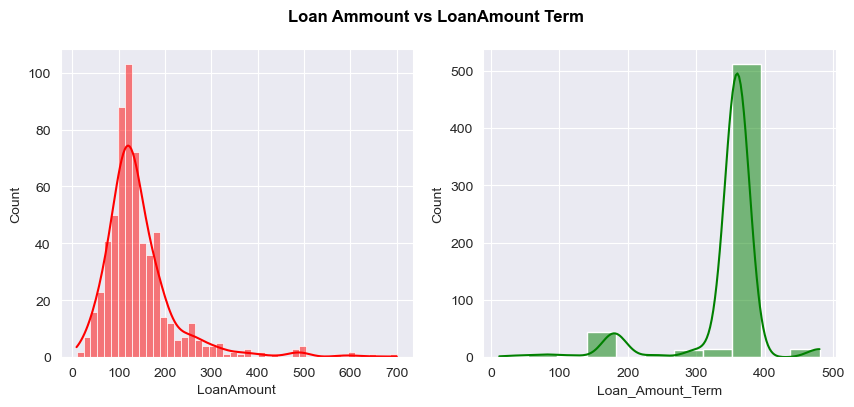

In [ ]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,2)
sns.histplot(df["Loan_Amount_Term"],kde=True,color="green")
plt.subplot(1,2,1)
sns.histplot(df["LoanAmount"],kde=True,color="red")
plt.suptitle("Loan Ammount vs LoanAmount Term",fontweight="bold",color="black")
plt.show()

In [ ]:
from pandas_profiling import ProfileReport
#eda=pr(df,dark_mode=True,explorative=True)
ed=ProfileReport(df,dark_mode=True,explorative=True)
ed

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

## Converting the text data to numerical data with the help of LabelEncoding

In [ ]:
ln=LabelEncoder()
for i in df:
    if df[i].dtypes=="object":
        df[i]=ln.fit_transform(df[i])

In [ ]:
df.tail()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,0,0,0,0,0,2900,0.0,71.0,360.0,1.0,0,1
610,1,1,3,0,0,4106,0.0,40.0,180.0,1.0,0,1
611,1,1,1,0,0,8072,240.0,253.0,360.0,1.0,2,1
612,1,1,2,0,0,7583,0.0,187.0,360.0,1.0,2,1
613,0,0,0,0,1,4583,0.0,133.0,360.0,0.0,1,0


In [ ]:
df[["male","Female"]]=pd.get_dummies(df["Gender"])
df[["Married","Unmarried"]]=pd.get_dummies(df["Married"])
df[["self_emp_yes","self_emp_No"]]=pd.get_dummies(df["Self_Employed"])

In [ ]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,male,Female,Unmarried,self_emp_yes,self_emp_No
0,1,1,0,0,0,5849,0.0,128.0,360.0,1.0,2,1,0,1,0,1,0
1,1,0,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0,0,1,1,1,0
2,1,0,0,0,1,3000,0.0,66.0,360.0,1.0,2,1,0,1,1,0,1
3,1,0,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1,0,1,1,1,0
4,1,1,0,0,0,6000,0.0,141.0,360.0,1.0,2,1,0,1,0,1,0


In [ ]:
df.drop(columns=['Gender','Self_Employed'],inplace=True)

In [ ]:
df.tail()

,Married,Dependents,Education,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,male,Female,Unmarried,self_emp_yes,self_emp_No
609,1,0,0,2900,0.0,71.0,360.0,1.0,0,1,1,0,0,1,0
610,0,3,0,4106,0.0,40.0,180.0,1.0,0,1,0,1,1,1,0
611,0,1,0,8072,240.0,253.0,360.0,1.0,2,1,0,1,1,1,0
612,0,2,0,7583,0.0,187.0,360.0,1.0,2,1,0,1,1,1,0
613,1,0,0,4583,0.0,133.0,360.0,0.0,1,0,1,0,0,0,1


In [ ]:
df.shape

(614, 15)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Married            614 non-null    uint8  
 1   Dependents         614 non-null    int32  
 2   Education          614 non-null    int32  
 3   ApplicantIncome    614 non-null    int64  
 4   CoapplicantIncome  614 non-null    float64
 5   LoanAmount         614 non-null    float64
 6   Loan_Amount_Term   614 non-null    float64
 7   Credit_History     614 non-null    float64
 8   Property_Area      614 non-null    int32  
 9   Loan_Status        614 non-null    int32  
 10  male               614 non-null    uint8  
 11  Female             614 non-null    uint8  
 12  Unmarried          614 non-null    uint8  
 13  self_emp_yes       614 non-null    uint8  
 14  self_emp_No        614 non-null    uint8  
dtypes: float64(4), int32(4), int64(1), uint8(6)
memory usage: 37.3 KB


In [ ]:
##Convert the unit8 data to Numerical data
ln=LabelEncoder()
for i in df:
    if df[i].dtypes=="uint8":
        df[i]=df[i].astype(int)


In [ ]:
# Complete INformation of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Married            614 non-null    int32  
 1   Dependents         614 non-null    int32  
 2   Education          614 non-null    int32  
 3   ApplicantIncome    614 non-null    int64  
 4   CoapplicantIncome  614 non-null    float64
 5   LoanAmount         614 non-null    float64
 6   Loan_Amount_Term   614 non-null    float64
 7   Credit_History     614 non-null    float64
 8   Property_Area      614 non-null    int32  
 9   Loan_Status        614 non-null    int32  
 10  male               614 non-null    int32  
 11  Female             614 non-null    int32  
 12  Unmarried          614 non-null    int32  
 13  self_emp_yes       614 non-null    int32  
 14  self_emp_No        614 non-null    int32  
dtypes: float64(4), int32(10), int64(1)
memory usage: 48.1 KB


In [ ]:
df.tail()

,Married,Dependents,Education,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,male,Female,Unmarried,self_emp_yes,self_emp_No
609,1,0,0,2900,0.0,71.0,360.0,1.0,0,1,1,0,0,1,0
610,0,3,0,4106,0.0,40.0,180.0,1.0,0,1,0,1,1,1,0
611,0,1,0,8072,240.0,253.0,360.0,1.0,2,1,0,1,1,1,0
612,0,2,0,7583,0.0,187.0,360.0,1.0,2,1,0,1,1,1,0
613,1,0,0,4583,0.0,133.0,360.0,0.0,1,0,1,0,0,0,1


In [ ]:
# Extract the features and label or Target
x=df.drop("Loan_Status",axis=1)
x.tail()

,Married,Dependents,Education,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,male,Female,Unmarried,self_emp_yes,self_emp_No
609,1,0,0,2900,0.0,71.0,360.0,1.0,0,1,0,0,1,0
610,0,3,0,4106,0.0,40.0,180.0,1.0,0,0,1,1,1,0
611,0,1,0,8072,240.0,253.0,360.0,1.0,2,0,1,1,1,0
612,0,2,0,7583,0.0,187.0,360.0,1.0,2,0,1,1,1,0
613,1,0,0,4583,0.0,133.0,360.0,0.0,1,1,0,0,0,1


In [ ]:
y=df[['Loan_Status']]
y.head()

,Loan_Status
0,1
1,0
2,1
3,1
4,1


## Standard Scalling the Features
* Standard scaling is a technique whereby the values in a column are rescaled so that they demonstrate the properties of a
  standard Gaussian distribution,
* where mean=0 and Varience=1

In [ ]:
sc=StandardScaler()

In [ ]:
x=sc.fit_transform(x)

In [ ]:
x

array([[ 1.37208932, -0.73780632, -0.52836225, ..., -1.37208932,
         0.39260074, -0.39260074],
       [-0.72881553,  0.25346957, -0.52836225, ...,  0.72881553,
         0.39260074, -0.39260074],
       [-0.72881553, -0.73780632, -0.52836225, ...,  0.72881553,
        -2.54711697,  2.54711697],
       ...,
       [-0.72881553,  0.25346957, -0.52836225, ...,  0.72881553,
         0.39260074, -0.39260074],
       [-0.72881553,  1.24474546, -0.52836225, ...,  0.72881553,
         0.39260074, -0.39260074],
       [ 1.37208932, -0.73780632, -0.52836225, ..., -1.37208932,
        -2.54711697,  2.54711697]])

In [ ]:
#Distribute the train and test data
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=14)
print("x"*100)
print(f"The shape of the x_train = {x_train.shape}")
print("x"*100)
print(f"The shape of the x_train = {x_test.shape}")
print("x"*100)
print(f"The shape of the x_train = {y_train.shape}")
print("x"*100)
print(f"The shape of the x_train = {y_test.shape}")
print("x"*100)

xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
The shape of the x_train = (429, 14)
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
The shape of the x_train = (185, 14)
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
The shape of the x_train = (429, 1)
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
The shape of the x_train = (185, 1)
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx


## Applying the Logistic Regression Model

In [ ]:
log=LogisticRegression()
log.fit(x_train,y_train)

LogisticRegression()

In [ ]:
pred=log.predict(x_test)
pred2=log.predict(x_train)
print("x"*100)
print(pred)
print("x"*100)

xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 0 1 0 1 1 1 1 0 1 1
 1 0 1 1 1 1 1 1 1 1 0 0 1 0 0 0 1 1 1 1 1 1 1 1 1 1 0 1 0 1 1 0 1 1 1 1 1
 1 0 1 1 1 1 1 0 0 0 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1
 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 1 0 1 0 1 0 1 1]
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx


In [ ]:
#ac=accuracy_score(pred,y_test)
ac=log.score(x_test,y_test)
ac_train=log.score(x_train,y_train)
print("x"*100)
print(f"Accuracy of the train model in Logistic Regression : {ac_train}")
print("x"*100)
print(f"Accuracy of the test model in Logistic Regression : {ac}")
print("x"*100)

xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
Accuracy of the train model in Logistic Regression : 0.8041958041958042
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
Accuracy of the test model in Logistic Regression : 0.827027027027027
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx


In [ ]:
cm=confusion_matrix(y_test,pred)

In [ ]:
print(cm)

[[ 31  31]
 [  1 122]]


xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx


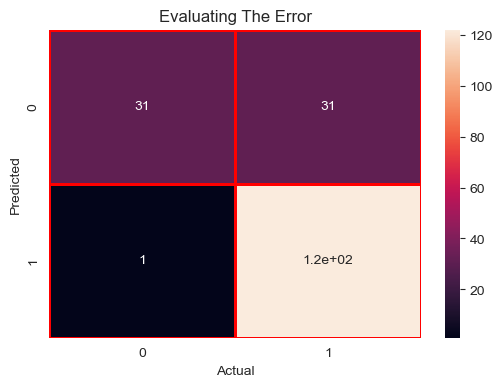

xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx


In [ ]:
print("x"*100)
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,linewidths=1,linecolor="red")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Evaluating The Error")
plt.show()
print("x"*100)

In [ ]:
clr=classification_report(y_test,pred)
print(clr)

              precision    recall  f1-score   support

           0       0.97      0.50      0.66        62
           1       0.80      0.99      0.88       123

    accuracy                           0.83       185
   macro avg       0.88      0.75      0.77       185
weighted avg       0.85      0.83      0.81       185



## Hyperparameter Tunning  With GridsearchCV

In [ ]:
lg=LogisticRegression()
param={"penalty":["l1","l2","elasticnet"],
       "C":[1,2,3,4,5,6,7,8,9,10,15,20,30,40],
       "max_iter":[100,200,300]}
param

{'penalty': ['l1', 'l2', 'elasticnet'],
 'C': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 30, 40],
 'max_iter': [100, 200, 300]}

In [ ]:
grd=GridSearchCV(lg,param_grid=param,scoring="accuracy",cv=5)
grd.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 30, 40],
                         'max_iter': [100, 200, 300],
                         'penalty': ['l1', 'l2', 'elasticnet']},
             scoring='accuracy')

In [ ]:
p=grd.best_params_
p

{'C': 1, 'max_iter': 100, 'penalty': 'l2'}

In [ ]:
grd.predict(x_test)

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       0, 1, 0, 1, 0, 1, 0, 1, 1])

In [ ]:
grd.best_score_

0.7926128590971272

In [ ]:
logs=LogisticRegression(C=1,max_iter=100,penalty='l2')
logs.fit(x_train,y_train)

LogisticRegression(C=1)

In [ ]:
logs.score(x_test,y_test)

0.827027027027027

In [ ]:
logs.score(x_train,y_train)

0.8041958041958042

xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx


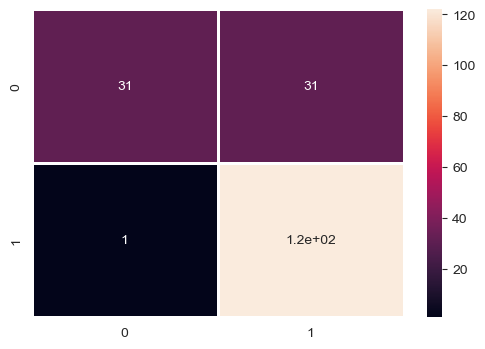

xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx


In [ ]:
print("x"*100)
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test,logs.predict(x_test)),annot=True,linecolor="white",linewidths=1)
plt.show()
print("x"*100)

## EDA (Exploratory Data Analysis)

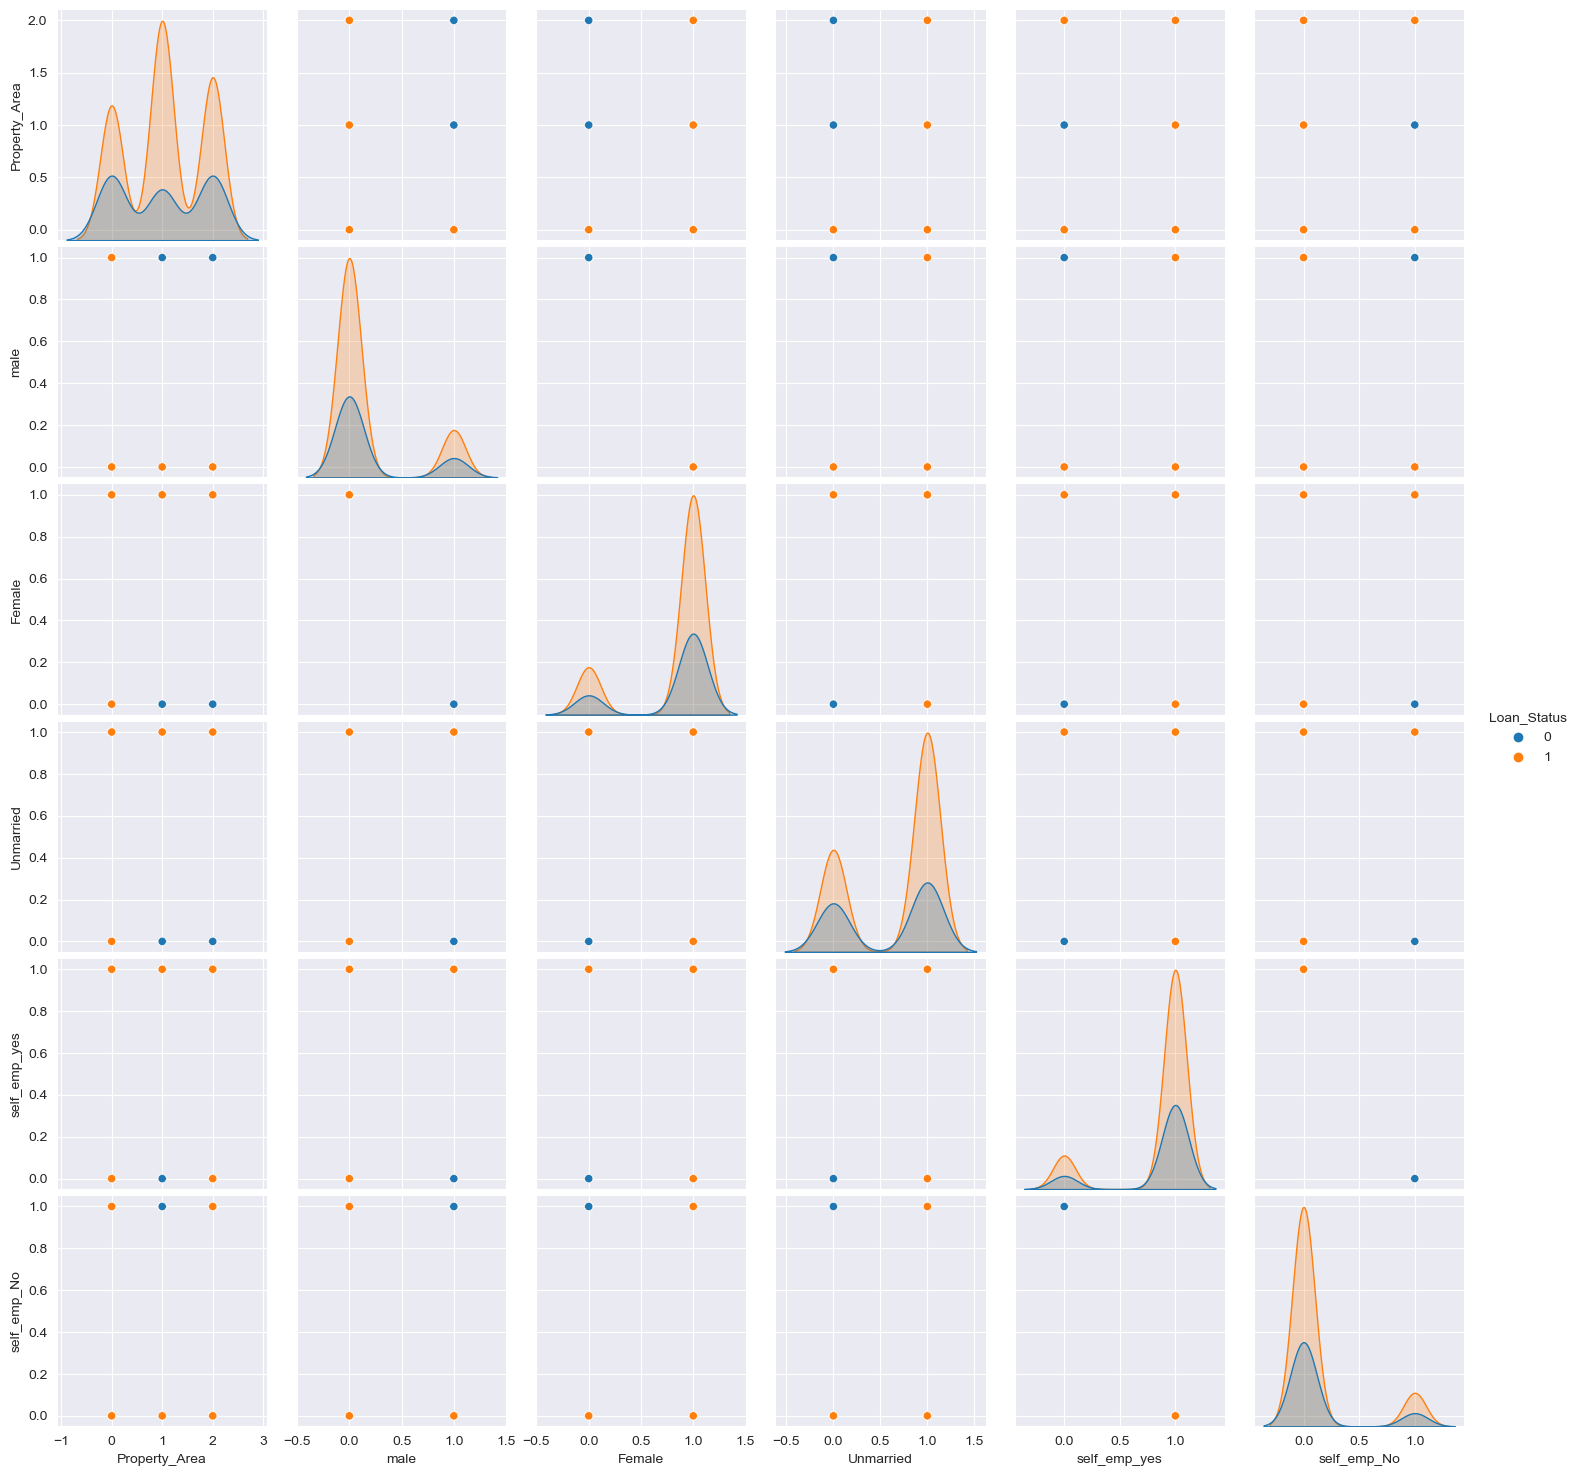

In [ ]:
sns.pairplot(df.iloc[0:,8:],hue="Loan_Status");

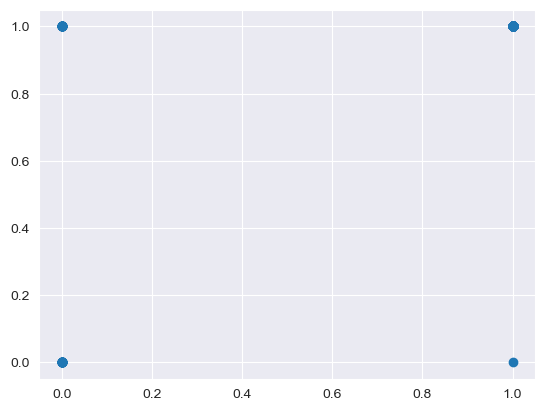

In [ ]:

plt.scatter(y_test,pred)

Logistic regression is also known as Binomial logistics regression. It is based on sigmoid function where output is probability and input can be from -infinity to +infinity. Let’s discuss some advantages and disadvantages of Linear Regression.

![Web%20capture_14-3-2023_214114_www.geeksforgeeks.org.jpeg](attachment:Web%20capture_14-3-2023_214114_www.geeksforgeeks.org.jpeg)

## I have completed my Logistic regression task